In [1]:
import sys
import os

print("--- Path Analysis and Memory Purge ---")

# --- Step 1: Fix the Search Path ---
incorrect_path = '/home/lwan/.local/lib/python3.10/site-packages'
if incorrect_path in sys.path:
    print(f"Found and removed incorrect path: {incorrect_path}")
    while incorrect_path in sys.path:
        sys.path.remove(incorrect_path)
else:
    print("Incorrect path not found in search path.")

# --- Step 2: Purge All NumPy Modules from Memory ---
# This is the crucial new part. We remove not just 'numpy', but all of its submodules.
numpy_modules = []
for module in sys.modules:
    if module == 'numpy' or module.startswith('numpy.'):
        numpy_modules.append(module)

if numpy_modules:
    print(f"Found and purged {len(numpy_modules)} cached NumPy modules.")
    for module in numpy_modules:
        del sys.modules[module]
else:
    print("No cached NumPy modules found to purge.")

# --- Step 3: Verification ---
try:
    import numpy
    print("\n--- Verification Complete ---")
    print(f"Current NumPy Version: {numpy.__version__}")
    print(f"Current NumPy Location: {numpy.__file__}")

    correct_path_prefix = '/exp/dune/data/users/ayankele/transformercvn_env'
    if correct_path_prefix in numpy.__file__:
        print("\n✅ Success! The kernel is now using the correct NumPy.")
    else:
        print("\n❌ Error! The kernel is still using an incorrect NumPy.")

except ImportError as e:
    print(f"\n❌ An ImportError occurred after cleaning: {e}")

# os.environ["CUDA_VISIBLE_DEVICES"] = ""

--- Path Analysis and Memory Purge ---
Found and removed incorrect path: /home/lwan/.local/lib/python3.10/site-packages
No cached NumPy modules found to purge.

--- Verification Complete ---
Current NumPy Version: 1.23.5
Current NumPy Location: /exp/dune/data/users/ayankele/transformercvn_env/lib/python3.10/site-packages/numpy/__init__.py

✅ Success! The kernel is now using the correct NumPy.


In [2]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F
torch.jit.script = lambda x: x

import re 
import h5py
from glob import glob
from functools import partial
from tqdm import tqdm

from tensorflow.python.summary.summary_iterator import summary_iterator

from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from scipy.spatial.distance import pdist, cdist
from scipy import stats

from transformercvn.network.trainers.neutrino_full_dense_trainer import NeutrinoFullDenseTrainer, sparse_to_dense
from transformercvn.network.trainers.neutrino_full_sparse_trainer import NeutrinoFullSparseTrainer
from transformercvn.network.trainers.neutrino_full_sdxl_trainer import NeutrinoFullSDXLTrainer
from transformercvn.dataset.minkowski_dataset import MinkowskiCollection
from transformercvn.options import Options

from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmasher as cmr
import seaborn as sb

2026-01-29 21:42:39.008010: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 21:42:39.363436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-29 21:42:39.376712: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-29 21:42:39.380708: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-29 21:42:39.753750: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instru

# Training History

In [3]:
tags = ['lr-AdamW/pg1',  # Learning Rate
        'val_epoch_accuracy', 'event_epoch_accuracy', 'prong_epoch_accuracy', # Validation accuracy, val = (event + prong)/2
        'train_loss', 'train_event_accuracy', 'train_prong_accuracy', # Possibly not helpful with small batch size
        'val_epoch_AUC', 'event_epoch_AUC', 'prong_epoch_AUC'] # ROC AUC, average='weighted'

In [4]:
# If training was stopped and restarted many times, this list can contain many tensorboards
tensorboards = ["./test/version_3/events.out.tfevents.1761920337.jupyter-lwan.165719.0"]

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


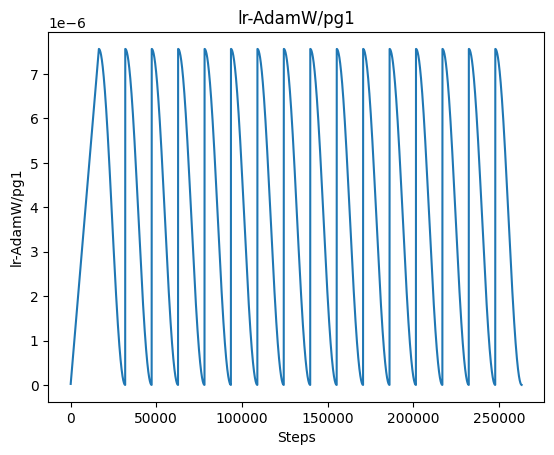

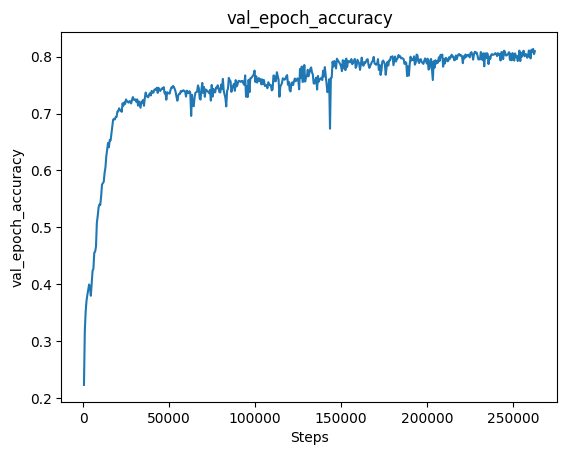

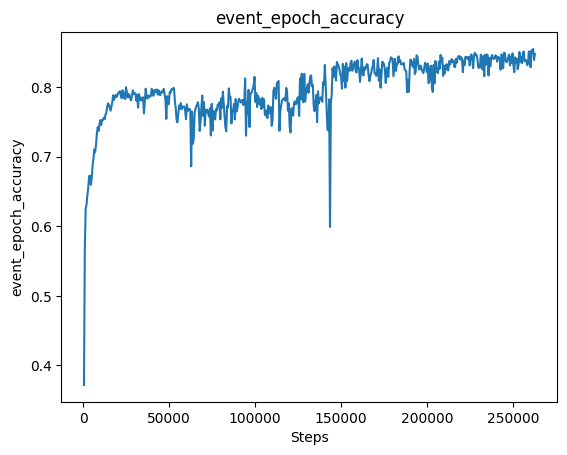

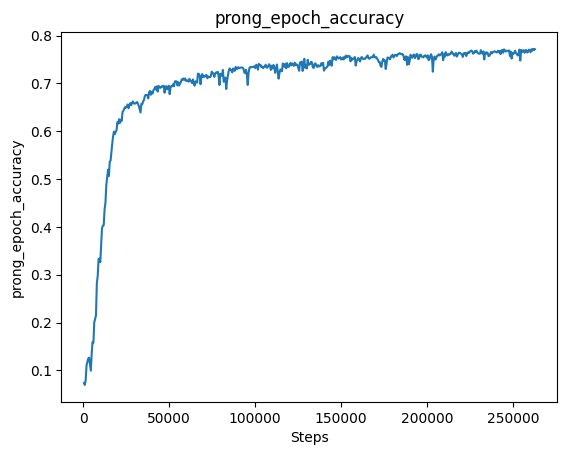

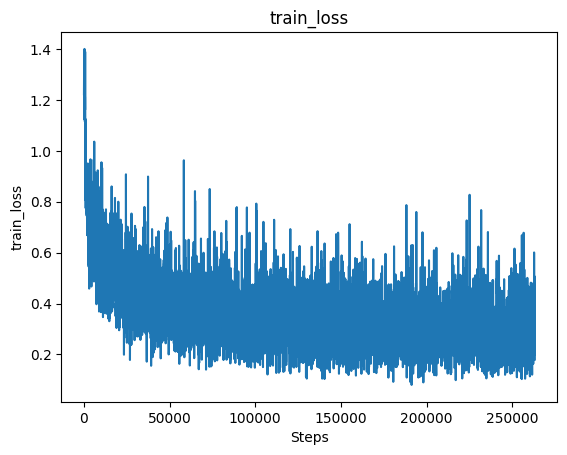

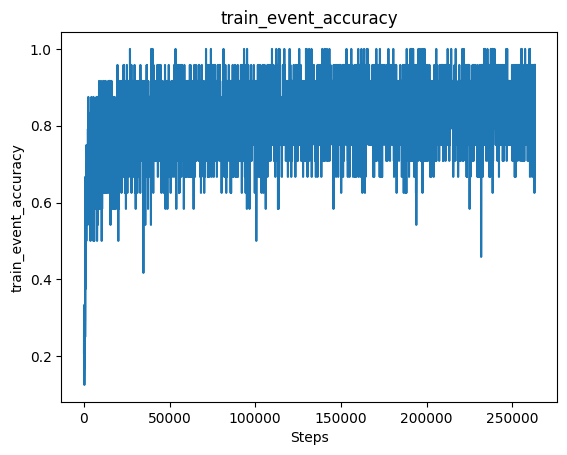

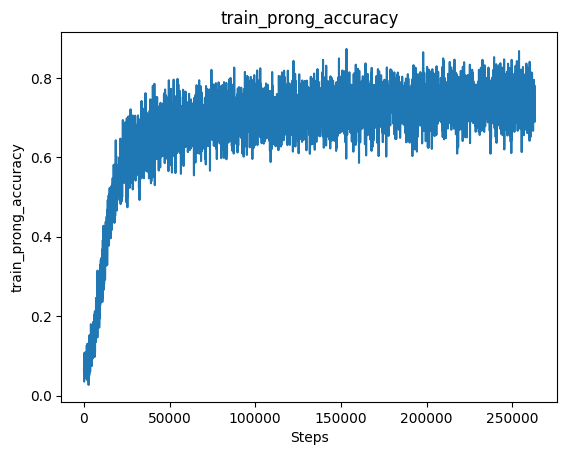

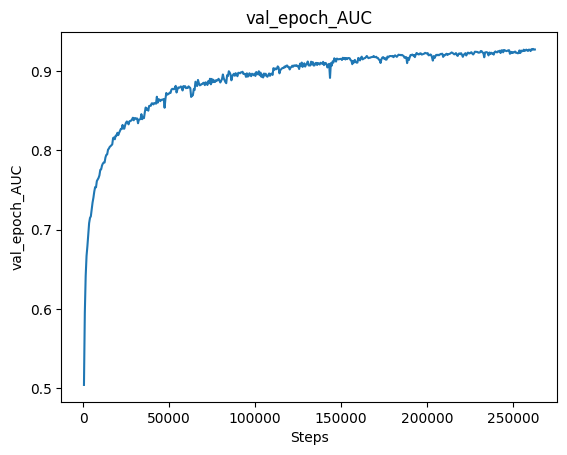

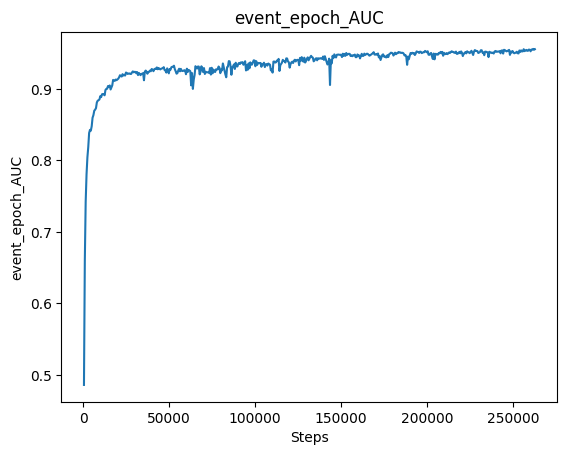

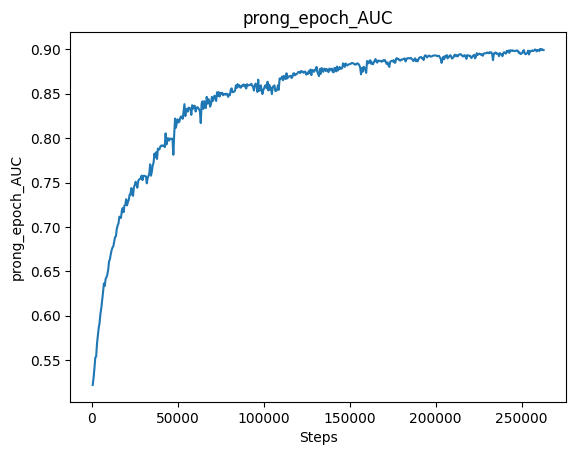

In [5]:
metrics = {tag:[] for tag in tags}

for tensorboard in tensorboards:
  for e in summary_iterator(tensorboard):
    for v in e.summary.value:
      #print(v)
      if v.tag in tags:
        metrics[v.tag].append([e.step, v.simple_value])
        last_step = e.step

for tag in tags:
    metric = np.array(metrics[tag])
    if metric.size==0:
        print("No values saved for metric", tag)
        continue
    plt.plot(metric[:,0], metric[:,1], label=tag)
    plt.xlabel('Steps')
    plt.ylabel(tag)
    plt.title(tag)
    #plt.legend()
    plt.show()

# Testing Dataset

In [6]:
CUDA = True
CUDA_DEVICE = 0
USE_TEX = False
TESTING_FILE = None

TESTING_SOURCE= "validation"
GRADIENT = False

NETWORK = NeutrinoFullDenseTrainer
#NETWORK = NeutrinoFullDenseTrainer
#NETWORK = NeutrinoFullSDXLTrainer

In [7]:
TESTING_FILE = "/exp/dune/data/users/linyan/detsum/Sparse/test.h5"
out_csv = "detsum_output/test.csv"
BASE_DIRECTORY = "./test/version_3/"
#CHECKPOINT_PATH = "./tutorial_dense/version_0/checkpoints/last.ckpt"
CHECKPOINT_PATH = "./test/version_3/checkpoints/last.ckpt"

In [8]:
options = Options.load(f"{BASE_DIRECTORY}/options.json")
if TESTING_FILE:
    options.testing_file = TESTING_FILE
else:
    options.testing_file = options.training_file.replace("training", TESTING_SOURCE)
options.num_dataloader_workers = 0
print(f"Testing file: {TESTING_FILE} {options.testing_file}")

if CHECKPOINT_PATH is None:
    checkpoints = glob(f"{BASE_DIRECTORY}/checkpoints/epoch*.ckpt")
    last_checkpoint = np.argmax([int(re.search("step=(.*).ckpt", s)[1]) for s in checkpoints])
    checkpoint_path = checkpoints[last_checkpoint]
else:
    checkpoint_path = CHECKPOINT_PATH
checkpoint = torch.load(checkpoint_path, map_location='cpu')
state_dict = checkpoint["state_dict"]
print(f"Loading from: {checkpoint_path}")

network = NETWORK(options)
network.load_state_dict(state_dict)

network = network.eval()

if not GRADIENT:
    for parameter in network.parameters():
        parameter.requires_grad_(False)

if CUDA:
    network = network.cuda(CUDA_DEVICE)

Testing file: /exp/dune/data/users/linyan/detsum/Sparse/test.h5 /exp/dune/data/users/linyan/detsum/Sparse/test.h5
Loading from: ./test/version_3/checkpoints/last.ckpt
num_events: 438834
self.min_limit: 0
self.max_limit: 394950
num_events: 438834
self.min_limit: 394951
self.max_limit: 438833
num_events: 18543
self.min_limit: 0
self.max_limit: 18542


In [9]:
#DATASET = network.training_dataset
#DATASET = network.validation_dataset
DATASET = network.testing_dataset

In [10]:
np.bincount(DATASET.event_targets)

array([    0,     0,     0, 18543])

In [11]:
dataloader_options = network.dataloader_options
dataloader_options["pin_memory"] = False
dataloader_options["num_workers"] = 0
dataloader_options["batch_size"] = 16
dataloader_options["drop_last"] = False

test_dataloader = network.dataloader(DATASET, **dataloader_options)

In [12]:
batch = next(iter(network.dataloader(DATASET, **dataloader_options)))

if CUDA:
    batch = [b.cuda(CUDA_DEVICE) for b in batch]

(
        features,
        extra,
        event_coordinates,
        event_pixel_values,
        event_masks,
        prong_coordinates,
        prong_pixel_values,
        prong_masks,
        event_target,
        prong_target
) = batch

event_logits, prong_logits = network.forward(
        features,
        extra,
        event_coordinates,
        event_pixel_values,
        event_masks,
        prong_coordinates,
        prong_pixel_values,
        prong_masks,
    )

In [13]:
event_predictions = []
prong_predictions = []

event_targets = []
prong_targets = []

event_raws = []
prong_raws = []

total_attentions = []

for batch_idx, batch in enumerate(tqdm(test_dataloader)):
    if CUDA:
        batch = [b.cuda(CUDA_DEVICE) for b in batch]
        
    (
            features,
            extra,
            event_coordinates,
            event_pixel_values,
            event_masks,
            prong_coordinates,
            prong_pixel_values,
            prong_masks,
            event_target,
            prong_target
    ) = batch
    
    event_logits, prong_logits = network.forward(
            features,
            extra,
            event_coordinates,
            event_pixel_values,
            event_masks,
            prong_coordinates,
            prong_pixel_values,
            prong_masks,
        )
    
    event_predictions.append(event_logits.argmax(-1).cpu())
    prong_predictions.append(prong_logits.argmax(-1).cpu())
    
    event_targets.append(event_target.cpu())
    prong_targets.append(prong_target.cpu())
    
    event_raws.append(event_logits.cpu())
    prong_raws.append(prong_logits.cpu())
            
event_targets = torch.cat(event_targets)
prong_targets = torch.cat(prong_targets)

event_predictions = torch.cat(event_predictions)
prong_predictions = torch.cat(prong_predictions)

event_raws = torch.cat(event_raws)
prong_raws = torch.cat(prong_raws)

prong_mask = prong_targets >= 0

100%|██████████| 1159/1159 [02:31<00:00,  7.64it/s]


In [14]:
event_probabilities = torch.softmax(event_raws, dim=1)
prong_probabilities = torch.softmax(prong_raws, dim=2)

In [15]:
flat_prong_probabilities = prong_probabilities[prong_mask]
flat_prong_predictions = prong_predictions[prong_mask]
flat_prong_targets = prong_targets[prong_mask]

In [16]:
event_probabilities # Score for [NumuCC, NueCC, NC, Other]
print(f"Shape of 'event_probabilities': {event_probabilities.shape}")

Shape of 'event_probabilities': torch.Size([18543, 4])


In [17]:
event_targets

tensor([3, 3, 3,  ..., 3, 3, 3], dtype=torch.int32)

In [18]:
prong_probabilities # Score for [Electron, Muon, Proton, Neutron,
                    #            Pi +/-, Pi0, Photon, Other]

tensor([[[4.1214e-03, 1.2077e-01, 4.2325e-02,  ..., 7.2840e-03,
          8.6349e-04, 2.2243e-03],
         [4.0030e-03, 1.7976e-02, 4.7462e-01,  ..., 1.0462e-02,
          6.3930e-04, 4.5701e-03],
         [1.0788e-02, 1.6942e-02, 4.8374e-01,  ..., 3.2671e-02,
          1.5103e-03, 6.8667e-03],
         ...,
         [1.7710e-01, 1.3258e-01, 1.8183e-01,  ..., 1.0397e-01,
          8.4502e-02, 1.1274e-01],
         [1.7710e-01, 1.3258e-01, 1.8183e-01,  ..., 1.0397e-01,
          8.4502e-02, 1.1274e-01],
         [1.7710e-01, 1.3258e-01, 1.8183e-01,  ..., 1.0397e-01,
          8.4502e-02, 1.1274e-01]],

        [[1.1289e-01, 6.4419e-03, 1.9723e-02,  ..., 7.9283e-01,
          3.5788e-02, 2.5810e-03],
         [3.4094e-03, 8.7958e-03, 6.4469e-01,  ..., 1.4686e-02,
          5.5188e-04, 4.4046e-03],
         [6.4662e-03, 1.5476e-02, 3.8429e-01,  ..., 3.4502e-02,
          1.1405e-03, 4.8347e-03],
         ...,
         [1.7710e-01, 1.3258e-01, 1.8183e-01,  ..., 1.0397e-01,
          8.450

In [19]:
prong_targets

tensor([[ 4,  4,  2,  ..., -1, -1, -1],
        [ 5,  2,  2,  ..., -1, -1, -1],
        [ 4,  5,  5,  ..., -1, -1, -1],
        ...,
        [ 2,  4,  2,  ..., -1, -1, -1],
        [ 4,  2,  2,  ..., -1, -1, -1],
        [ 5,  5,  5,  ..., -1, -1, -1]], dtype=torch.int8)

In [20]:
with h5py.File(BASE_DIRECTORY+"eval_predictions.h5", "w") as file:
    file.create_dataset("event_probabilities", data=event_probabilities.numpy())
    file.create_dataset("event_predictions", data=event_predictions.numpy())
    file.create_dataset("event_targets", data=event_predictions.numpy())
    
    file.create_dataset("prong_probabilities", data=prong_probabilities.numpy())
    file.create_dataset("prong_predictions", data=prong_predictions.numpy())
    file.create_dataset("prong_targets", data=prong_targets.numpy())

In [21]:
from contextlib import redirect_stdout
import pandas as pd

def to_1d(name, x):
    a = np.asarray(x).squeeze()
    if a.ndim != 1:
        raise ValueError(f"{name} is not 1D after squeeze: shape={a.shape}")
    return a

with h5py.File(TESTING_FILE, "r") as file:
    test_target = file["event_target"][:]
    genies_nmult = file["genie_nmult"][:] 
    genies_np = file["genie_np"][:] 
    genies_npi0 = file["genie_npi0"][:] 
    genies_npic = file["genie_npic"][:] 
    genies_sum_px = file["genie_sum_px"][:] 
    genies_sum_py = file["genie_sum_py"][:] 
    genies_sum_pz = file["genie_sum_pz"][:] 
    genies_sum_ke = file["genie_sum_ke"][:] 
    genies_sphericity = file["genie_sphericity"][:] 
    genies_aplanarity = file["genie_aplanarity"][:] 
    genies_file_name = np.char.decode(file["file_name"][:], "utf-8")

decision_threshold = 0.9507
event_probabilities_np = event_probabilities.numpy()
probs = np.asarray(event_probabilities_np).squeeze()

cols = {
    "test_target": test_target,
    "file_name": genies_file_name,
    "genie_nmult": genies_nmult,
    "genie_np": genies_np,
    "genie_npi0": genies_npi0,
    "genie_npic": genies_npic,
    "genie_sum_px": genies_sum_px,
    "genie_sum_py": genies_sum_py,
    "genie_sum_pz": genies_sum_pz,
    "genie_sum_ke": genies_sum_ke,
    "genie_sphericity": genies_sphericity,
    "genie_aplanarity": genies_aplanarity,
    "probs": probs,
    "event_probabilities_np": event_probabilities_np
}

for k, v in cols.items():
    a = np.asarray(v)
    print(k, a.shape, a.dtype)

df = pd.DataFrame({
    "file_name": to_1d("file_name", genies_file_name),
    "genie_nmult": to_1d("genie_nmult", genies_nmult),
    "genie_np": to_1d("genie_np", genies_np),
    "genie_npi0": to_1d("genie_npi0", genies_npi0),
    "genie_npic": to_1d("genie_npic", genies_npic),
    "genie_sum_px": to_1d("genie_sum_px", genies_sum_px),
    "genie_sum_py": to_1d("genie_sum_py", genies_sum_py),
    "genie_sum_pz": to_1d("genie_sum_pz", genies_sum_pz),
    "genie_sum_ke": to_1d("genie_sum_ke", genies_sum_ke),
    "genie_sphericity": to_1d("genie_sphericity", genies_sphericity),
    "genie_aplanarity": to_1d("genie_aplanarity", genies_aplanarity),
    "nnbar_score": probs[:, 3],
    "pass_cut": (probs[:, 3] >= decision_threshold),
})

ijk = df["file_name"].str.extract(r'etau_(\d+)alpha_(\d+)beta_(\d+)_')
ijk.columns = ["etau", "alpha", "beta"]
df[["i", "j", "k"]] = ijk.astype("Int64")

etau_vals = np.array([5, 10.4, 18, 30], dtype=float)
alpha_vals  = np.array([0.87, 0.91, 0.93, 0.95, 0.99, 0.88, 0.98], dtype=float)
beta_vals     = np.array([0.206, 0.210, 0.212, 0.214, 0.218], dtype=float)

etau_map = dict(enumerate(etau_vals))
alpha_map  = dict(enumerate(alpha_vals))
beta_map     = dict(enumerate(beta_vals))

df["etau"]  = df["i"].map(etau_map)
df["alpha"] = df["j"].map(alpha_map)
df["beta"]  = df["k"].map(beta_map)

cols = ["etau", "alpha", "beta", "genie_nmult", "genie_np", "genie_npi0", "genie_npic", "genie_sum_px", "genie_sum_py", "genie_sum_pz", "genie_sum_ke", "genie_sphericity", "genie_aplanarity", "nnbar_score", "pass_cut"]
df[cols].to_csv(out_csv, index=True, index_label="event_number")
print(f"Wrote: {out_csv} (rows={len(df)})")


test_target (18543,) int32
file_name (18543, 1) <U114
genie_nmult (18543, 1) int8
genie_np (18543, 1) int8
genie_npi0 (18543, 1) int8
genie_npic (18543, 1) int8
genie_sum_px (18543, 1) float32
genie_sum_py (18543, 1) float32
genie_sum_pz (18543, 1) float32
genie_sum_ke (18543, 1) float32
genie_sphericity (18543, 1) float32
genie_aplanarity (18543, 1) float32
probs (18543, 4) float32
event_probabilities_np (18543, 4) float32
Wrote: detsum_output/test.csv (rows=18543)
